In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aub_htp.random import DiscreteSampler
from aub_htp.random import IsotropicSampler, EllipticSampler, MixedSampler, DiscreteSampler, sample_alpha_stable_vector

alpha = 0.5

sigma = [[10, 0],
         [0, 100]]

isotropic_mass = 10

# ---- Isotropic ----
sampler_isotropic = IsotropicSampler(2, isotropic_mass)
x_isotropic = sample_alpha_stable_vector(alpha, sampler_isotropic, 20000)

# ---- Elliptic ----
sampler_elliptic = EllipticSampler(2, sigma)
x_elliptic = sample_alpha_stable_vector(alpha, sampler_elliptic, 20000)

# ---- Discrete ----
positions = [
    [10, -10],
    [5, -5],
    [0, 0],
    [-5, 5],
    [-10, 10],
]
weights = np.ones(len(positions))/len(positions)

sampler_discrete = DiscreteSampler(positions, weights)
x_discrete = sample_alpha_stable_vector(alpha, sampler_discrete, 20000)

# ---- Mixed ----
sampler_mixed = MixedSampler([sampler_isotropic, sampler_discrete], [0.90, 0.10])
x_mixed = sample_alpha_stable_vector(alpha, sampler_mixed, 20000)


# ---- Plot side by side ----
x = [x_isotropic, x_elliptic, x_discrete, x_mixed]

fig, axes = plt.subplots(1, len(x), figsize=(12, 12))

for i, xi in enumerate(x):
    axes[i].scatter(xi.T[0], xi.T[1], s=1)
    axes[i].set_xlim(-100, 100)
    axes[i].set_ylim(-100, 100)
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'aub_htp'

ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.

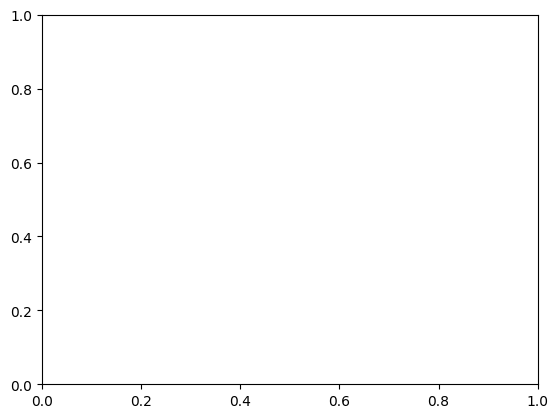

In [2]:
from aub_htp import generate_alpha_stable_pdf
from aub_htp.random import sample_alpha_stable_vector, UnivariateSampler
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

alpha = 1.8
beta = 0
xmin,xmax = -10, 10

univariate = UnivariateSampler(alpha, beta, gamma = 1)
samples = sample_alpha_stable_vector(alpha, univariate, 200000, [0]).T[0]
samples = samples[np.where((samples >= xmin)  & (samples <= xmax))]
_, bins, _ = ax.hist(samples, bins = 2000, density = True)

x = (bins[:-1] + bins[1:]) / 2

y = generate_alpha_stable_pdf(x, alpha, beta, 1, 0)

ax.plot(x, y)
ax.set_xlim(xmin, xmax)

In [1]:
from aub_htp import alpha_stable
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

alpha = 1.4
beta = 0
xmin,xmax = -10, 10

samples = alpha_stable.rvs(alpha, beta, size = 10000)
samples = samples[np.where((samples >= xmin)  & (samples <= xmax))]
hist_density, bins, _ = ax.hist(samples, bins = 2000, density = True)

x = (bins[:-1] + bins[1:]) / 2

y = alpha_stable.pdf(x, alpha, beta)

mse = np.mean((hist_density - y) ** 2)

ax.plot(x, y)
ax.set_xlim(xmin, xmax)


ModuleNotFoundError: No module named 'aub_htp'